# Data Split - Chia Tách Dữ Liệu

## 1. Import Libraries và Thiết Lập

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Thiết lập đường dẫn
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "cleaned" / "integrated_dataset_encoded.csv"
OUTPUT_DIR = BASE_DIR / "outputs" / "data_split"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

## 2. Load và Khám Phá Dữ Liệu

In [2]:
# Đọc dữ liệu
df = pd.read_csv(DATA_PATH)
df = df.loc[:, ~df.columns.duplicated()]

print(f"📊 Tổng số mẫu: {len(df):,}")
print(f"👥 Tổng số users: {df['user_idx'].nunique():,}")
print(f"🎬 Tổng số movies: {df['movie_idx'].nunique():,}")
print(f"\n📋 Thông tin dataset:")
df.info()

📊 Tổng số mẫu: 10,411
👥 Tổng số users: 3,506
🎬 Tổng số movies: 2,679

📋 Thông tin dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10411 entries, 0 to 10410
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                10411 non-null  object 
 1   movie_id               10411 non-null  int64  
 2   movie_title            10411 non-null  object 
 3   rating                 10411 non-null  float64
 4   cast                   10411 non-null  object 
 5   release_year           10411 non-null  int64  
 6   language               10411 non-null  object 
 7   genres_list            10411 non-null  object 
 8   primary_genre          10411 non-null  object 
 9   genre_count            10411 non-null  int64  
 10  source                 10411 non-null  object 
 11  rating_scaled          10411 non-null  float64
 12  genre_action           10411 non-null  int64  
 13  genre_adventure

In [ ]:
# Hiển thị mẫu dữ liệu
df.head()

## 3. Group-Based Split

Sử dụng GroupShuffleSplit để đảm bảo mỗi user chỉ xuất hiện trong một tập duy nhất (train, val, hoặc test).

In [3]:
# Chia 70% Train, 30% cho phần còn lại (Val + Test)
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=SEED)
train_idx, temp_idx = next(gss.split(df, groups=df['user_idx']))

train_df = df.iloc[train_idx]
temp_df = df.iloc[temp_idx]

print(f"✅ Train set: {len(train_df):,} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"⏳ Temp set (Val+Test): {len(temp_df):,} samples ({len(temp_df)/len(df)*100:.1f}%)")

✅ Train set: 6,862 samples (65.9%)
⏳ Temp set (Val+Test): 3,549 samples (34.1%)


In [4]:
# Chia 30% còn lại thành 50/50 -> 15% Val và 15% Test
gss_val_test = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
val_idx, test_idx = next(gss_val_test.split(temp_df, groups=temp_df['user_idx']))

val_df = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]

print(f"✅ Validation set: {len(val_df):,} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"✅ Test set: {len(test_df):,} samples ({len(test_df)/len(df)*100:.1f}%)")

✅ Validation set: 1,557 samples (15.0%)
✅ Test set: 1,992 samples (19.1%)


## 4. Kiểm Tra Tính Hợp Lệ

Đảm bảo không có user nào xuất hiện trong nhiều hơn một tập.

In [6]:
# Kiểm tra overlap giữa các tập
train_users = set(train_df['user_idx'].unique())
val_users = set(val_df['user_idx'].unique())
test_users = set(test_df['user_idx'].unique())

print("🔍 Kiểm tra overlap:")
print(f"Train ∩ Val: {len(train_users & val_users)} users")
print(f"Train ∩ Test: {len(train_users & test_users)} users")
print(f"Val ∩ Test: {len(val_users & test_users)} users")

if len(train_users & val_users) == 0 and len(train_users & test_users) == 0 and len(val_users & test_users) == 0:
    print("\n✅ Không có overlap - Split hợp lệ!")
else:
    print("\n⚠️ Có overlap - Cần kiểm tra lại!")

🔍 Kiểm tra overlap:
Train ∩ Val: 0 users
Train ∩ Test: 0 users
Val ∩ Test: 0 users

✅ Không có overlap - Split hợp lệ!


## 5. Thống Kê Chi Tiết

In [7]:
# Tạo bảng thống kê
stats_data = {
    'Split': ['Train', 'Validation', 'Test', 'Total'],
    'Samples': [len(train_df), len(val_df), len(test_df), len(df)],
    'Users': [len(train_users), len(val_users), len(test_users), df['user_idx'].nunique()],
    'Movies': [train_df['movie_idx'].nunique(), val_df['movie_idx'].nunique(), 
               test_df['movie_idx'].nunique(), df['movie_idx'].nunique()],
    'Sample %': [len(train_df)/len(df)*100, len(val_df)/len(df)*100, 
                 len(test_df)/len(df)*100, 100.0]
}

stats_df = pd.DataFrame(stats_data)
stats_df

,Split,Samples,Users,Movies,Sample %
0,Train,6862,2454,2305,65.911056
1,Validation,1557,526,1037,14.955336
2,Test,1992,526,1376,19.133609
3,Total,10411,3506,2679,100.000000


## 6. Visualization

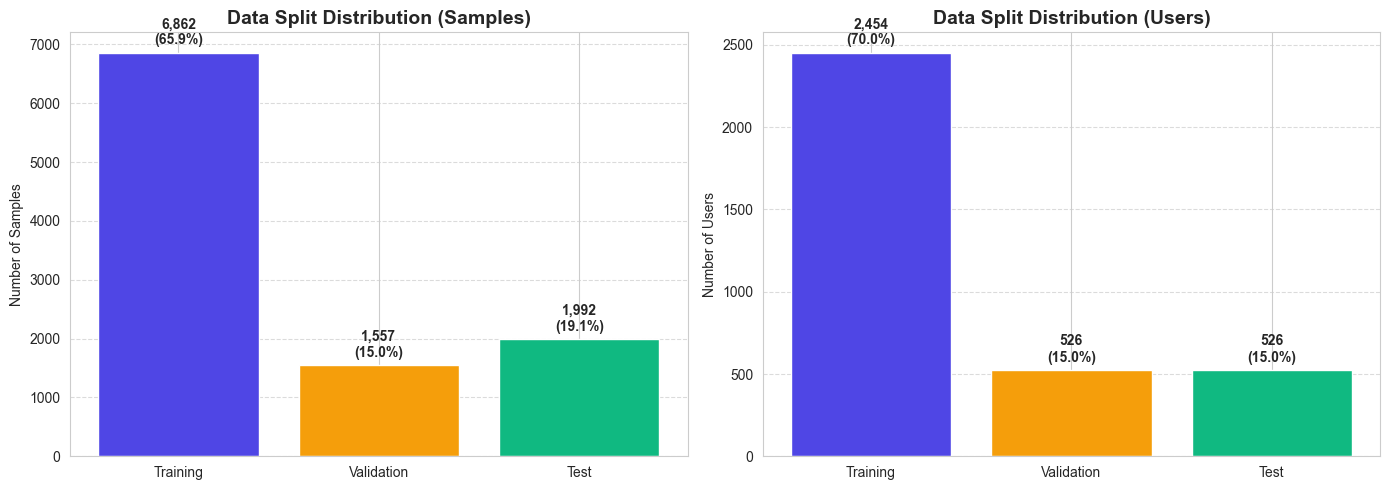

In [8]:
# Biểu đồ phân phối samples
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Sample distribution
labels = ['Training', 'Validation', 'Test']
sizes = [len(train_df), len(val_df), len(test_df)]
colors = ['#4f46e5', '#f59e0b', '#10b981']

axes[0].bar(labels, sizes, color=colors)
axes[0].set_title('Data Split Distribution (Samples)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(sizes):
    axes[0].text(i, v + max(sizes)*0.02, f"{v:,}\n({v/len(df)*100:.1f}%)", 
                ha='center', fontweight='bold')

# Subplot 2: User distribution
user_sizes = [len(train_users), len(val_users), len(test_users)]
axes[1].bar(labels, user_sizes, color=colors)
axes[1].set_title('Data Split Distribution (Users)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Users')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(user_sizes):
    axes[1].text(i, v + max(user_sizes)*0.02, f"{v:,}\n({v/df['user_idx'].nunique()*100:.1f}%)", 
                ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "split_viz.png", dpi=300, bbox_inches='tight')
plt.show()

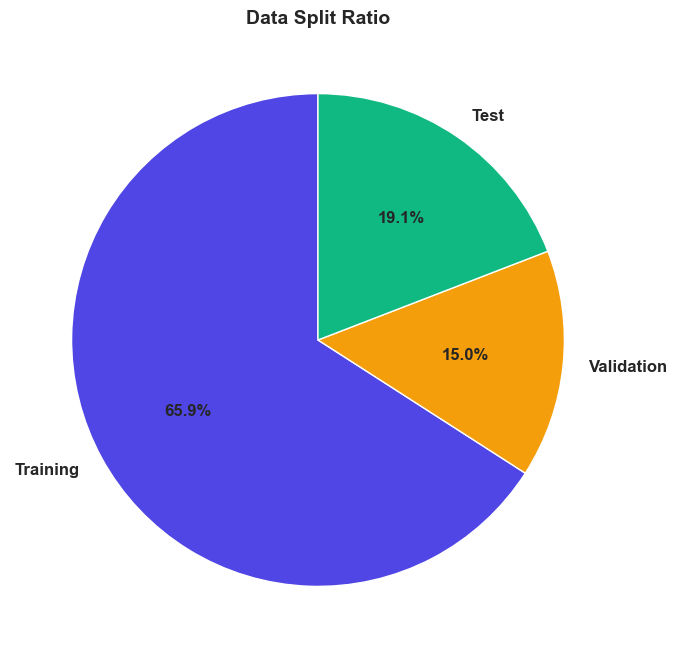

In [9]:
# Pie chart
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', 
       startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('Data Split Ratio', fontsize=14, fontweight='bold')
plt.savefig(OUTPUT_DIR / "split_pie.png", dpi=300, bbox_inches='tight')
plt.show()

## 7. Lưu Dữ Liệu

In [ ]:
# Lưu CSV
train_df.to_csv(OUTPUT_DIR / "train.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test.csv", index=False)

print("✅ Đã lưu train.csv, val.csv, test.csv")

In [ ]:
# Lưu Split Indices (Parquet)
indices_df = pd.DataFrame({
    "index": df.index,
    "split": "train"
})
indices_df.loc[val_df.index, "split"] = "val"
indices_df.loc[test_df.index, "split"] = "test"

indices_df.to_parquet(OUTPUT_DIR / "split_indices.parquet", engine='pyarrow', index=False)
print("✅ Đã lưu split_indices.parquet")

In [ ]:
# Lưu Sampling Report
report = {
    "metadata": {
        "seed": SEED,
        "split_strategy": "GroupShuffleSplit (User-based)",
        "target_ratios": {"train": 0.7, "val": 0.15, "test": 0.15}
    },
    "stats": {
        "total_samples": len(df),
        "total_users": int(df['user_idx'].nunique()),
        "train": {
            "samples": len(train_df), 
            "users": int(train_df['user_idx'].nunique()), 
            "ratio": len(train_df)/len(df)
        },
        "val": {
            "samples": len(val_df), 
            "users": int(val_df['user_idx'].nunique()), 
            "ratio": len(val_df)/len(df)
        },
        "test": {
            "samples": len(test_df), 
            "users": int(test_df['user_idx'].nunique()), 
            "ratio": len(test_df)/len(df)
        }
    }
}

with open(OUTPUT_DIR / "sampling_report.json", "w", encoding='utf-8') as f:
    json.dump(report, f, indent=4, ensure_ascii=False)

print("✅ Đã lưu sampling_report.json")

## 8. Tổng Kết

Quá trình chia tách dữ liệu đã hoàn thành với các đặc điểm:

- **Phương pháp**: Group-based Split (theo user_idx)
- **Tỷ lệ**: 70% Train, 15% Validation, 15% Test
- **Đảm bảo**: Không có user nào xuất hiện trong nhiều hơn một tập
- **Outputs**: train.csv, val.csv, test.csv, split_indices.parquet, sampling_report.json